<a href="https://colab.research.google.com/github/thapasujal01/iris-dataset-visualization/blob/main/projectRecreatingMaster_SujalThapa_cpsma4313.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd                  # Data loading and manipulation
import numpy as np                   # Numerical operations
import matplotlib.pyplot as plt      # Core plotting library
import matplotlib.patches as mpatches  # Custom legend handles
import warnings
warnings.filterwarnings('ignore')

# matplotlib is the primary visualization package used throughout this course.
# No additional third-party packages beyond pandas/numpy/matplotlib are required.

print('All packages loaded successfully.')


All packages loaded successfully.


In [5]:
import subprocess, sys

# gdown converts a Google Drive share link into a direct download — no login needed
# It is not covered in class; included here to avoid manual CSV downloads.
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'gdown', '-q'])
import gdown

# ── Paste your Google Drive shareable link here ───────────────────────────
# Example: 'https://drive.google.com/file/d/1AbCdEfGhIjKlMnOpQrStUv/view?usp=sharing'
GDRIVE_SHARE_URL = 'https://drive.google.com/file/d/1EidV5VHegUQc6n3IEzDnpGOtEYRaH0hx/view?usp=sharing'

# ── Download and load into DataFrame ─────────────────────────────────────
# gdown extracts the file ID from the share URL and downloads the file directly.
output_path = 'rotten_tomatoes_movies.csv'
gdown.download(url=GDRIVE_SHARE_URL, output=output_path, quiet=False, fuzzy=True)

df = pd.read_csv(output_path)

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(3)


Downloading...
From: https://drive.google.com/uc?id=1EidV5VHegUQc6n3IEzDnpGOtEYRaH0hx
To: /content/rotten_tomatoes_movies.csv
100%|██████████| 17.1M/17.1M [00:00<00:00, 249MB/s]


Shape: (17712, 22)
Columns: ['rotten_tomatoes_link', 'movie_title', 'movie_info', 'critics_consensus', 'content_rating', 'genres', 'directors', 'authors', 'actors', 'original_release_date', 'streaming_release_date', 'runtime', 'production_company', 'tomatometer_status', 'tomatometer_rating', 'tomatometer_count', 'audience_status', 'audience_rating', 'audience_count', 'tomatometer_top_critics_count', 'tomatometer_fresh_critics_count', 'tomatometer_rotten_critics_count']


,rotten_tomatoes_link,movie_title,movie_info,critics_consensus,content_rating,genres,directors,authors,actors,original_release_date,...,production_company,tomatometer_status,tomatometer_rating,tomatometer_count,audience_status,audience_rating,audience_count,tomatometer_top_critics_count,tomatometer_fresh_critics_count,tomatometer_rotten_critics_count
0,m/0814255,Percy Jackson & the Olympians: The Lightning T...,"Always trouble-prone, the life of teenager Per...",Though it may seem like just another Harry Pot...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,"Craig Titley, Chris Columbus, Rick Riordan","Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-02-12,...,20th Century Fox,Rotten,49.0,149.0,Spilled,53.0,254421.0,43,73,76
1,m/0878835,Please Give,Kate (Catherine Keener) and her husband Alex (...,Nicole Holofcener's newest might seem slight i...,R,Comedy,Nicole Holofcener,Nicole Holofcener,"Catherine Keener, Amanda Peet, Oliver Platt, R...",2010-04-30,...,Sony Pictures Classics,Certified-Fresh,87.0,142.0,Upright,64.0,11574.0,44,123,19
2,m/10,10,"A successful, middle-aged Hollywood songwriter...",Blake Edwards' bawdy comedy may not score a pe...,R,"Comedy, Romance",Blake Edwards,Blake Edwards,"Dudley Moore, Bo Derek, Julie Andrews, Robert ...",1979-10-05,...,Waner Bros.,Fresh,67.0,24.0,Spilled,53.0,14684.0,2,16,8


In [7]:
# Step 1: Keep only the columns we need
cols = ['movie_title', 'tomatometer_rating', 'audience_rating']
clean = df[cols].copy()

# Step 2: Drop rows missing either score
# We cannot compute a meaningful gap without both scores.
before = len(clean)
clean = clean.dropna(subset=['tomatometer_rating', 'audience_rating'])
print(f'Dropped {before - len(clean)} rows with missing scores. Remaining: {len(clean)}')

# Step 3: Ensure scores are numeric and in 0-100 range
clean['tomatometer_rating'] = pd.to_numeric(clean['tomatometer_rating'], errors='coerce')
clean['audience_rating']    = pd.to_numeric(clean['audience_rating'],    errors='coerce')

# Some audience scores may be on a 0-5 scale; normalise those
if clean['audience_rating'].max() <= 5:
    clean['audience_rating'] = clean['audience_rating'] * 20
    print('Audience rating normalised from 0-5 to 0-100 scale.')

# Drop any rows that failed numeric conversion
clean = clean.dropna(subset=['tomatometer_rating', 'audience_rating'])

# Step 4: Compute disagreement gap (positive = audience rated higher)
clean['gap'] = clean['audience_rating'] - clean['tomatometer_rating']

# Step 5: Remove duplicate titles (keep first occurrence)
clean = clean.drop_duplicates(subset='movie_title')

print(f'Final clean dataset shape: {clean.shape}')
clean.describe()


Dropped 305 rows with missing scores. Remaining: 17407
Final clean dataset shape: (16817, 4)


,tomatometer_rating,audience_rating,gap
count,16817.000000,16817.000000,16817.000000
mean,60.864363,60.675745,-0.188619
std,28.437938,20.539609,21.571085
min,0.000000,0.000000,-86.000000
25%,38.000000,45.000000,-14.000000
50%,67.000000,63.000000,-2.000000
75%,86.000000,78.000000,13.000000
max,100.000000,100.000000,95.000000


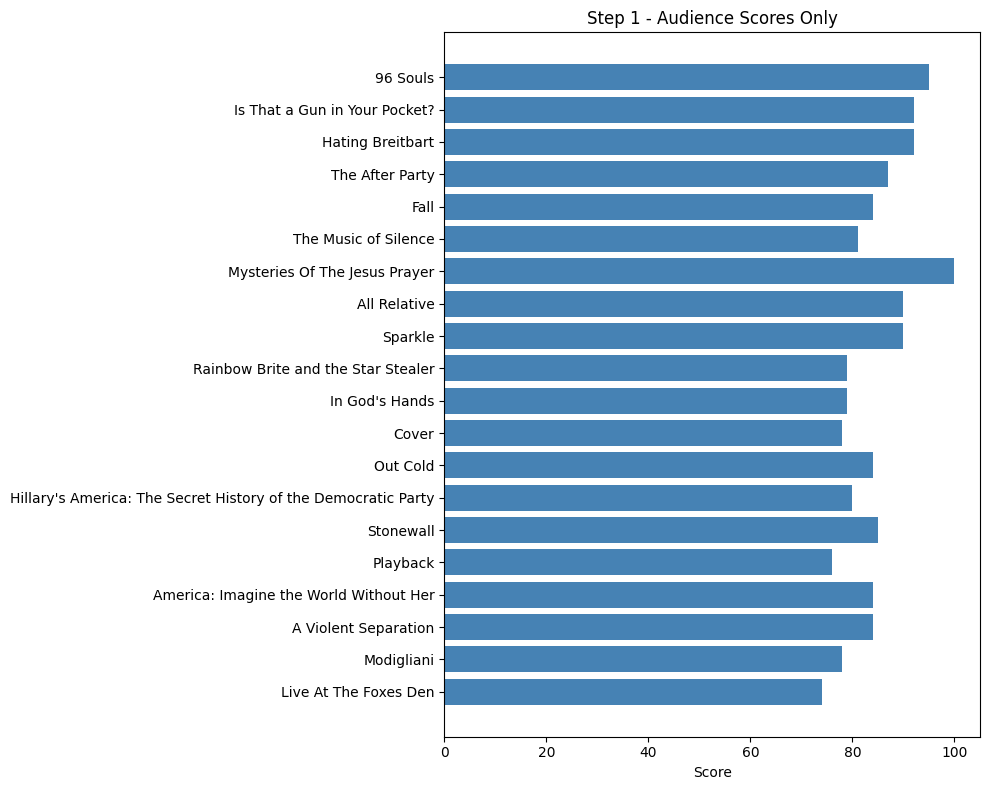

In [8]:
# Select top 20 movies where audiences loved but critics hated
TOP_N = 20
loved_by_audience = (
    clean[clean['gap'] > 0]
    .nlargest(TOP_N, 'gap')
    .sort_values('gap')
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(loved_by_audience['movie_title'], loved_by_audience['audience_rating'], color='steelblue')
ax.set_xlabel('Score')
ax.set_title('Step 1 - Audience Scores Only')
plt.tight_layout()
plt.show()


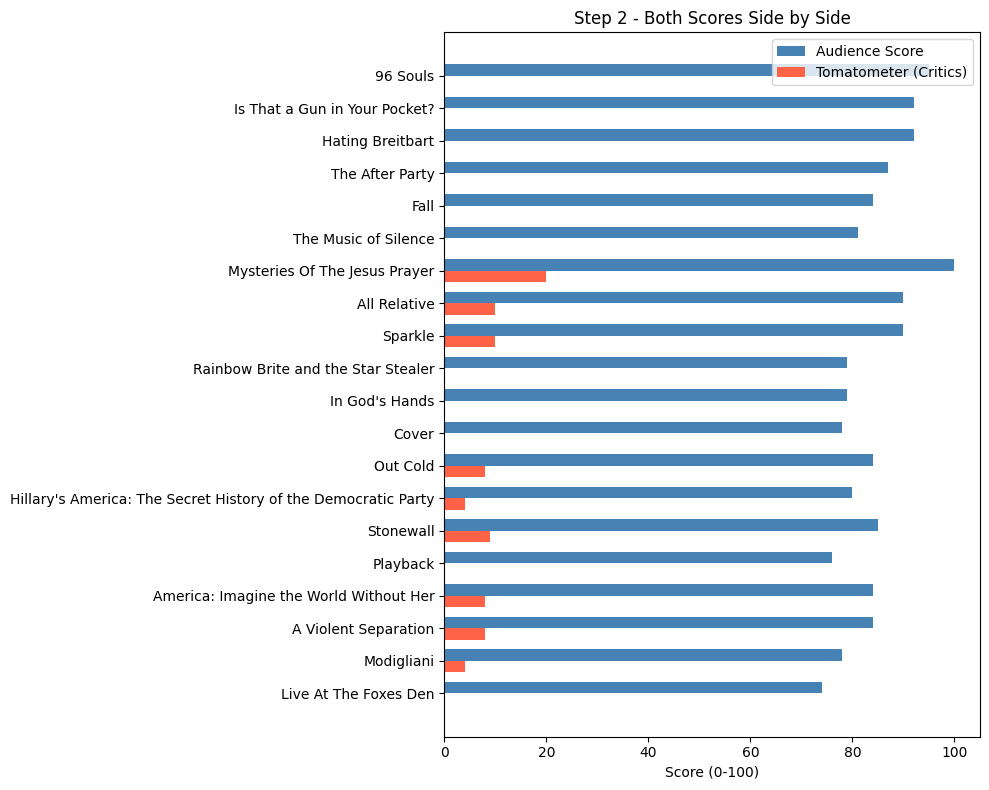

In [9]:
y     = range(len(loved_by_audience))
bar_h = 0.35

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh([i + bar_h/2 for i in y], loved_by_audience['audience_rating'],
        height=bar_h, color='steelblue', label='Audience Score')
ax.barh([i - bar_h/2 for i in y], loved_by_audience['tomatometer_rating'],
        height=bar_h, color='tomato',    label='Tomatometer (Critics)')
ax.set_yticks(list(y))
ax.set_yticklabels(loved_by_audience['movie_title'])
ax.legend()
ax.set_xlabel('Score (0-100)')
ax.set_title('Step 2 - Both Scores Side by Side')
plt.tight_layout()
plt.show()


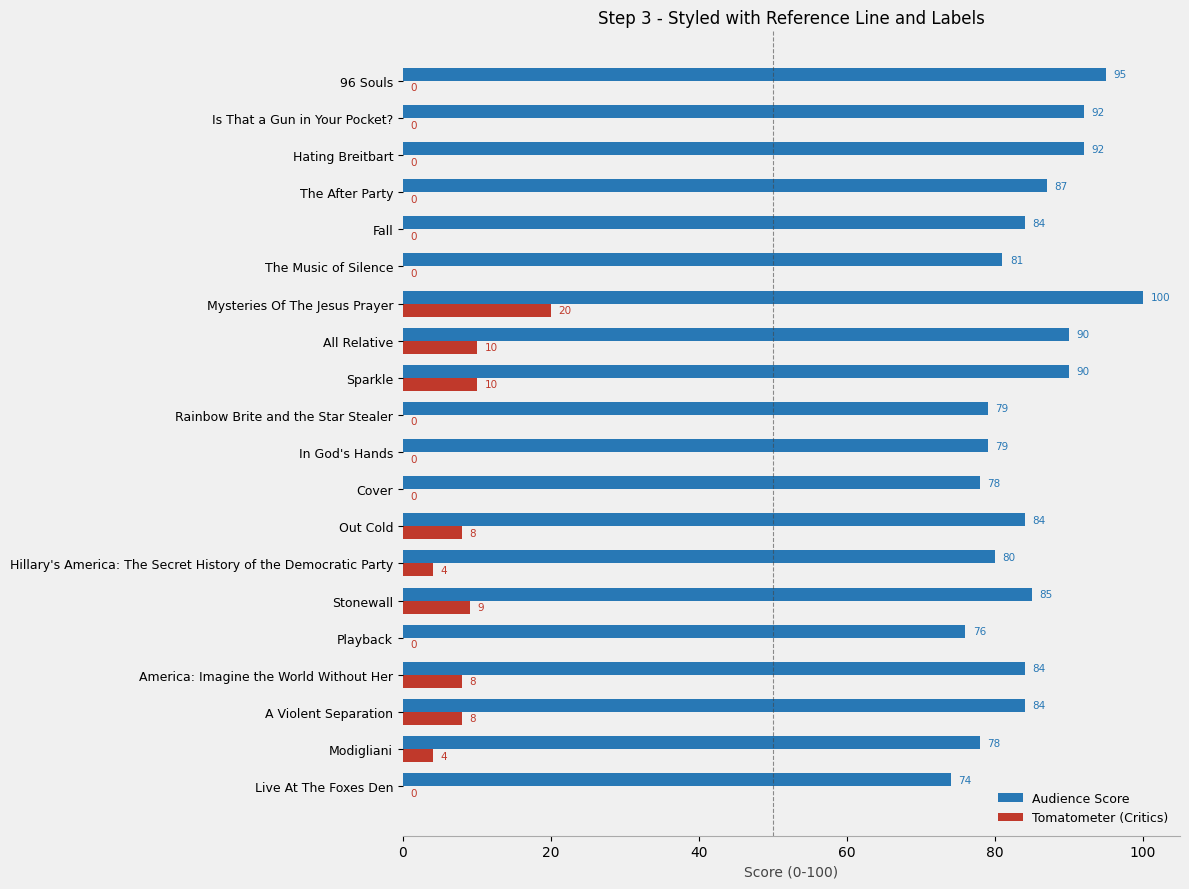

In [10]:
BG     = '#F0F0F0'
C_AUD  = '#2878B5'
C_CRIT = '#C0392B'

fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

bars_aud  = ax.barh([i + bar_h/2 for i in y], loved_by_audience['audience_rating'],
                    height=bar_h, color=C_AUD,  label='Audience Score')
bars_crit = ax.barh([i - bar_h/2 for i in y], loved_by_audience['tomatometer_rating'],
                    height=bar_h, color=C_CRIT, label='Tomatometer (Critics)')

ax.set_yticks(list(y))
ax.set_yticklabels(loved_by_audience['movie_title'], fontsize=9)
ax.axvline(50, color='#444444', linewidth=0.8, linestyle='--', alpha=0.6)

for bar in bars_aud:
    w = bar.get_width()
    ax.text(w + 1, bar.get_y() + bar.get_height()/2,
            f'{w:.0f}', va='center', fontsize=7.5, color=C_AUD)
for bar in bars_crit:
    w = bar.get_width()
    ax.text(w + 1, bar.get_y() + bar.get_height()/2,
            f'{w:.0f}', va='center', fontsize=7.5, color=C_CRIT)

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#AAAAAA')
ax.set_xlabel('Score (0-100)', fontsize=10, color='#444444')
ax.legend(frameon=False, fontsize=9)
ax.set_title('Step 3 - Styled with Reference Line and Labels')
plt.tight_layout()
plt.show()


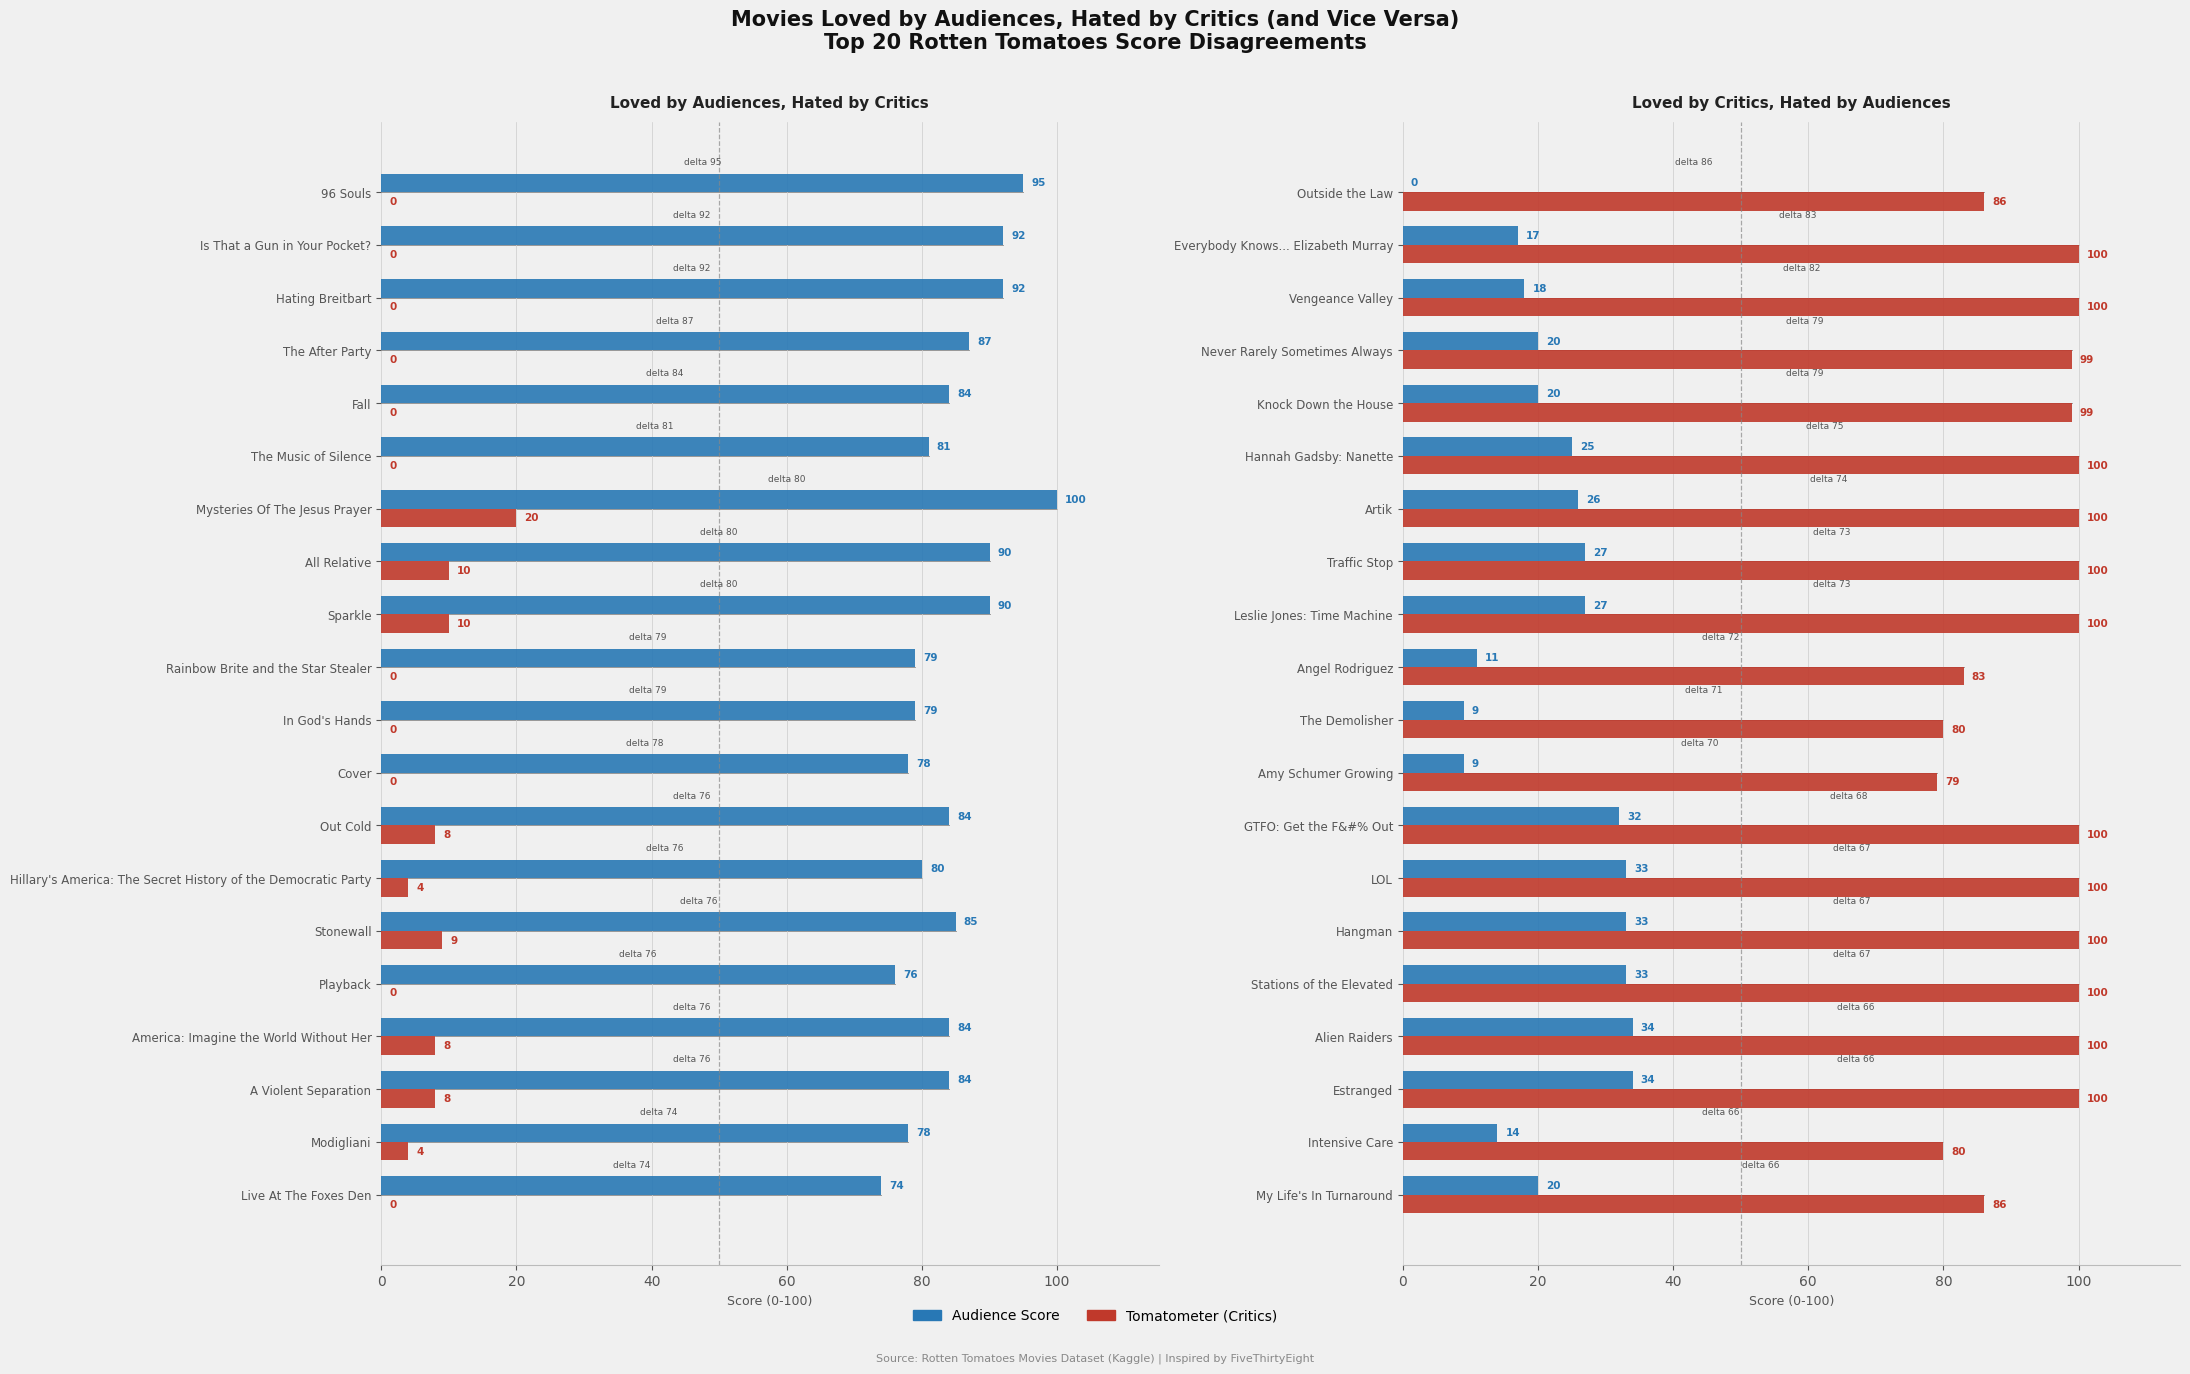

Figure saved as final_visualization.png


In [11]:
TOP_N  = 20
BG     = '#F0F0F0'
C_AUD  = '#2878B5'
C_CRIT = '#C0392B'
BAR_H  = 0.35

# Audiences loved, critics hated
aud_loved = (
    clean[clean['gap'] > 0]
    .nlargest(TOP_N, 'gap')
    .sort_values('gap', ascending=True)
    .reset_index(drop=True)
)

# Critics loved, audiences hated
crit_loved = (
    clean[clean['gap'] < 0]
    .nsmallest(TOP_N, 'gap')
    .sort_values('gap', ascending=False)
    .reset_index(drop=True)
)

def draw_panel(ax, data, title):
    """Draw one panel of the dual-panel chart."""
    y = range(len(data))
    ax.set_facecolor(BG)

    bars_aud = ax.barh(
        [i + BAR_H/2 for i in y], data['audience_rating'],
        height=BAR_H, color=C_AUD, alpha=0.90, label='Audience Score'
    )
    bars_crit = ax.barh(
        [i - BAR_H/2 for i in y], data['tomatometer_rating'],
        height=BAR_H, color=C_CRIT, alpha=0.90, label='Tomatometer (Critics)'
    )

    # Connector line between bar tips to show gap
    for i, row in data.iterrows():
        ax.plot(
            [row['tomatometer_rating'], row['audience_rating']], [i, i],
            color='#888888', linewidth=0.6, zorder=0
        )

    # Score labels at bar ends
    for bar in bars_aud:
        w = bar.get_width()
        ax.text(w + 1.2, bar.get_y() + bar.get_height()/2,
                f'{w:.0f}', va='center', fontsize=7.5, color=C_AUD, fontweight='bold')
    for bar in bars_crit:
        w = bar.get_width()
        ax.text(w + 1.2, bar.get_y() + bar.get_height()/2,
                f'{w:.0f}', va='center', fontsize=7.5, color=C_CRIT, fontweight='bold')

    # Gap delta label above connector
    for i, row in data.iterrows():
        mid = (row['tomatometer_rating'] + row['audience_rating']) / 2
        ax.text(mid, i + 0.48, f"delta {abs(row['gap']):.0f}",
                ha='center', va='bottom', fontsize=6.5, color='#555555')

    ax.set_yticks(list(y))
    ax.set_yticklabels(data['movie_title'], fontsize=8.5)
    ax.axvline(50, color='#888888', linewidth=0.9, linestyle='--', alpha=0.7)

    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_color('#BBBBBB')
    ax.tick_params(colors='#555555')
    ax.set_xlim(0, 115)
    ax.set_xlabel('Score (0-100)', fontsize=9, color='#555555')
    ax.set_title(title, fontsize=11, fontweight='bold', color='#222222', pad=10)
    ax.xaxis.grid(True, color='#CCCCCC', linewidth=0.5, linestyle='-')
    ax.set_axisbelow(True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 13))
fig.patch.set_facecolor(BG)

draw_panel(ax1, aud_loved,  'Loved by Audiences, Hated by Critics')
draw_panel(ax2, crit_loved, 'Loved by Critics, Hated by Audiences')

aud_patch  = mpatches.Patch(color=C_AUD,  label='Audience Score')
crit_patch = mpatches.Patch(color=C_CRIT, label='Tomatometer (Critics)')
fig.legend(handles=[aud_patch, crit_patch],
           loc='lower center', ncol=2, fontsize=10,
           frameon=False, bbox_to_anchor=(0.5, -0.01))

fig.suptitle(
    'Movies Loved by Audiences, Hated by Critics (and Vice Versa)\n'
    'Top 20 Rotten Tomatoes Score Disagreements',
    fontsize=15, fontweight='bold', color='#111111', y=1.01
)
fig.text(0.5, -0.03,
         'Source: Rotten Tomatoes Movies Dataset (Kaggle) | '
         'Inspired by FiveThirtyEight',
         ha='center', fontsize=8, color='#888888')

plt.tight_layout()
plt.savefig('final_visualization.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()
print('Figure saved as final_visualization.png')
